# Correlated noise

Produces Figure 6.

In [1]:
import sys
sys.path.insert(0, "..")   # make src importable from the repository root

from src.utils import load_results

results = load_results("correlated_noise")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.figstyle import (DASHES, PALETTE, PT, figure,
                          panel_label, param_colors, save_figure,
                          share_y, threshold_line, use_manuscript_style)

use_manuscript_style()


Wrote figures/fig6_correlated_noise.pdf


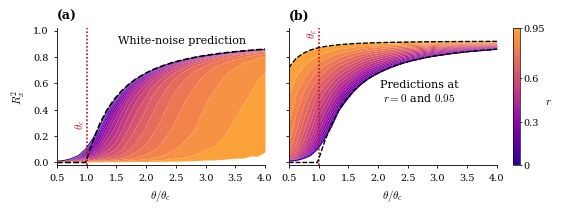

r=0.00: supercritical MAE naive 0.0037, whitened 0.0037
r=0.50: supercritical MAE naive 0.0714, whitened 0.0025
r=0.95: supercritical MAE naive 0.6749, whitened 0.0023
20 correlation levels, cond from 1.0 to 1374.5
toeplitz naive/whitened MAE: 0: 0.004/0.004, 0.3: 0.023/0.003, 0.6: 0.115/0.002, 0.9: 0.547/0.002
factor naive/whitened MAE: 0: 0.004/0.004, 1: 0.689/0.004, 3: 0.690/0.004, 10: 0.690/0.004


In [3]:
HEIGHT_PT = 146.0

field = results['toeplitz_field']
sweeps = field['sweeps']
r_fine = sorted(float(r) for r in sweeps)
theta_norm = np.asarray(field['theta_values']) / field['theta_c']

R_MAX = float(max(r_fine))
cols, sm = param_colors('r', np.asarray(r_fine), vmin=0.0, vmax=R_MAX,
                        lo=0.05, hi=0.80)
band_cols, _ = param_colors(
    'r', (np.asarray(r_fine)[:-1] + np.asarray(r_fine)[1:]) / 2,
    vmin=0.0, vmax=R_MAX, lo=0.05, hi=0.80)

fig, axes = figure(HEIGHT_PT, 2)
ax_a, ax_b = axes

for ax, key in ((ax_a, 'Rx2_naive_mean'), (ax_b, 'Rx2_whitened_mean')):
    M = np.array([sweeps[r][key] for r in r_fine])
    for i in range(len(r_fine) - 1):
        ax.fill_between(theta_norm, M[i + 1], M[i], color=band_cols[i], lw=0,
                        zorder=2)
    for row, c in zip(M[[0, -1]], cols[[0, -1]]):
        ax.plot(theta_norm, row, color=c, lw=0.7, zorder=3)

ax_a.plot(theta_norm, field['theory_naive'], color=PALETTE['theory'], lw=1.2,
          ls=DASHES['theory_alt'], zorder=7)
label_x_a = 2.6
ax_a.text(label_x_a, float(np.interp(label_x_a, theta_norm, field['theory_naive'])) + 0.11,
          'White-noise prediction', color=PALETTE['theory'],
          fontsize=PT['annot'], ha='center', va='bottom', zorder=9)
for r in (r_fine[0], r_fine[-1]):
    ax_b.plot(theta_norm, sweeps[r]['theory_whitened_mean'],
              color=PALETTE['theory'], lw=1.0, ls=DASHES['theory_alt'], zorder=7)
lo_pred = sweeps[r_fine[0]]['theory_whitened_mean']
label_x_b = 2.7
ax_b.text(label_x_b, float(np.interp(label_x_b, theta_norm, lo_pred)) - 0.16,
          f'Predictions at\n$r=0$ and ${R_MAX:g}$', color=PALETTE['theory'],
          fontsize=PT['annot'], ha='center', va='top', linespacing=1.15,
          zorder=9)

threshold_line(ax_a, 1.0, r'$\theta_c$', y=0.30, lw=1.2)
threshold_line(ax_b, 1.0, r'$\theta_c$', y=0.96, lw=1.2)
for ax, letter in ((ax_a, '(a)'), (ax_b, '(b)')):
    ax.set_xlabel(r'$\theta/\theta_c$')
    ax.set_xlim(theta_norm.min(), theta_norm.max())
    panel_label(ax, letter)

share_y(axes, r'$R_x^2$')
ax_a.set_ylim(-0.02, 1.02)

cb = fig.colorbar(sm, ax=list(axes), location='right', fraction=0.035, pad=0.02)
cb.set_label(r'$r$', fontsize=PT['axis'], labelpad=2, rotation=0)
cb.set_ticks([0.0, 0.3, 0.6, R_MAX])
cb.set_ticklabels(['0', '0.3', '0.6', f'{R_MAX:g}'])
cb.ax.tick_params(labelsize=PT['tick'], length=1.5, width=0.5, pad=1)
cb.outline.set_linewidth(0.5)

save_figure(fig, 'fig6_correlated_noise')
plt.show()

mask_super = theta_norm > 1.1   # supercritical signals
for r in (r_fine[0], r_fine[len(r_fine) // 2], r_fine[-1]):
    s = sweeps[r]
    nai = np.abs(s['Rx2_naive_mean'] - field['theory_naive'])[mask_super].mean()
    wht = np.abs(s['Rx2_whitened_mean'] - s['theory_whitened_mean'])[mask_super].mean()
    print(f'r={r:.2f}: supercritical MAE naive {nai:.4f}, whitened {wht:.4f}')
print(f'{len(r_fine)} correlation levels, cond from '
      f'{sweeps[r_fine[0]]["cond"]:.1f} to {sweeps[r_fine[-1]]["cond"]:.1f}')


diagnostics = results['covariance_diagnostics']
diagnostic_mask = (np.asarray(diagnostics['theta_values']) /
                   diagnostics['theta_c'] > 1.1)
for family in ('toeplitz', 'factor'):
    values = []
    for level, sweep in diagnostics[family].items():
        naive = np.abs(np.asarray(sweep['Rx2_naive_mean']) -
                       diagnostics['theory_naive'])[diagnostic_mask].mean()
        white = np.abs(np.asarray(sweep['Rx2_whitened_mean']) -
                       np.asarray(sweep['theory_whitened_mean']))[diagnostic_mask].mean()
        values.append(f'{level:g}: {naive:.3f}/{white:.3f}')
    print(f'{family} naive/whitened MAE: ' + ', '.join(values))
